# Milestone 3 MVP: Danger in Cruising Locations in the Damron Guides

## Historical Question
Did the proportion of cruising locations marked as dangerous increase between the earlier and later years of the *Damron Guides*? 

## MVP Argument
This notebook builds a computational pipeline that identifies cruising locations, flags locations associated with danger warnings, calculates yearly percentages, and compares an early period to a later period. It also includes a robustness check showing how different data-cleaning choices can change the historical interpretation.

## Why this is an MVP
This project is designed as a proof of concept. The goal is to show that the dataset and code can work together to answer a specific historical question, rather than simply reproducing a graph.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import os

# Convert .rds → CSV using R (no Python packages needed)
os.system('Rscript -e "df <- readRDS(\'data.rds\'); write.csv(df, \'data_converted.csv\', row.names=FALSE)"')

0

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_converted.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(60698, 13)
['ID', 'title', 'description', 'streetaddress', 'type', 'amenityfeatures', 'city', 'state', 'Year', 'notes', 'lat', 'lon', 'status']


,ID,title,description,streetaddress,type,amenityfeatures,city,state,Year,notes,lat,lon,status
0,3213,'B.A.',(woods & ponds),NaN,Cruising Areas,Cruisy Area,Lake Placid,NY,1982,NaN,44.279491,-73.979871,Location could not be verified. General city o...
1,2265,'B.A.' Beach,2 mi. E.,Rte. 2,Cruising Areas,Cruisy Area,Troy,NY,1981,NaN,42.728412,-73.691785,Location could not be verified. General city o...
2,3269,'B.A.' Beach,nr. Salt Air Beach,NaN,Cruising Areas,Cruisy Area,Salt Lake City,UT,1981,NaN,40.747813,-112.187268,Location could not be verified. General city o...
3,3388,'B.A.' Beach,nr. Evergreen Floating Bridge,NaN,Cruising Areas,Cruisy Area,Seattle,WA,1981,NaN,47.606210,-122.332071,Location could not be verified. General city o...
4,3508,'B.A.' Beach,(2 mi. E. on Rte. 2),NaN,Cruising Areas,Cruisy Area,Troy,NY,1982,NaN,42.728412,-73.691785,Location could not be verified. General city o...


## Data Preparation

Before analysis, the dataset must be cleaned to ensure consistency. Missing values in key columns such as `amenityfeatures` and `description` are filled, and the `Year` variable is converted into a usable numeric format. This step ensures that the pipeline can reliably group and compare data over time.

In [7]:
# Clean important columns
df["amenityfeatures"] = df["amenityfeatures"].fillna("")
df["description"] = df["description"].fillna("")
df["type"] = df["type"].fillna("")

# Make sure Year is usable
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Year"]).copy()
df["Year"] = df["Year"].astype(int)

df.head()

,ID,title,description,streetaddress,type,amenityfeatures,city,state,Year,notes,lat,lon,status
0,3213,'B.A.',(woods & ponds),NaN,Cruising Areas,Cruisy Area,Lake Placid,NY,1982,NaN,44.279491,-73.979871,Location could not be verified. General city o...
1,2265,'B.A.' Beach,2 mi. E.,Rte. 2,Cruising Areas,Cruisy Area,Troy,NY,1981,NaN,42.728412,-73.691785,Location could not be verified. General city o...
2,3269,'B.A.' Beach,nr. Salt Air Beach,NaN,Cruising Areas,Cruisy Area,Salt Lake City,UT,1981,NaN,40.747813,-112.187268,Location could not be verified. General city o...
3,3388,'B.A.' Beach,nr. Evergreen Floating Bridge,NaN,Cruising Areas,Cruisy Area,Seattle,WA,1981,NaN,47.606210,-122.332071,Location could not be verified. General city o...
4,3508,'B.A.' Beach,(2 mi. E. on Rte. 2),NaN,Cruising Areas,Cruisy Area,Troy,NY,1982,NaN,42.728412,-73.691785,Location could not be verified. General city o...


## Identifying Cruising Locations and Danger Indicators

To focus the analysis, I first isolate locations labeled as "Cruisy" in the dataset. These represent the subset of locations relevant to the historical question.

I then identify locations associated with danger indicators by searching for specific labels ("HOT" and "AYOR") within the same field. These labels function as warnings and serve as a proxy for perceived risk.

In [8]:
# Find cruising locations
cruisy_places = df[df["amenityfeatures"].str.contains("Cruisy", case=False, regex=False)].copy()

# Find danger-marked locations
danger_places = cruisy_places[
    cruisy_places["amenityfeatures"].str.contains("HOT|AYOR", case=False, regex=True)
].copy()

print("Total rows:", len(df))
print("Cruisy locations:", len(cruisy_places))
print("Danger-marked cruisy locations:", len(danger_places))

Total rows: 60698
Cruisy locations: 12928
Danger-marked cruisy locations: 1708


## Calculating Yearly Percentages

To track changes over time, I compute the percentage of cruising locations marked with danger indicators for each year. This is done by dividing the number of danger-marked locations by the total number of cruising locations in that year.

In [9]:
# Count by year
all_cruisy_by_year = cruisy_places.groupby("Year").size().sort_index()
danger_cruisy_by_year = danger_places.groupby("Year").size().sort_index()

# Build table
yearly_table = pd.DataFrame({
    "Total_Cruisy": all_cruisy_by_year,
    "Danger_Cruisy": danger_cruisy_by_year
}).fillna(0)

# Percentage
yearly_table["Percent_Dangerous"] = (
    yearly_table["Danger_Cruisy"] / yearly_table["Total_Cruisy"]
) * 100

yearly_table.head()

,Total_Cruisy,Danger_Cruisy,Percent_Dangerous
Year,,,
1965,1,0.0,0.000000
1966,3,0.0,0.000000
1969,1,0.0,0.000000
1971,1,0.0,0.000000
1972,165,1.0,0.606061


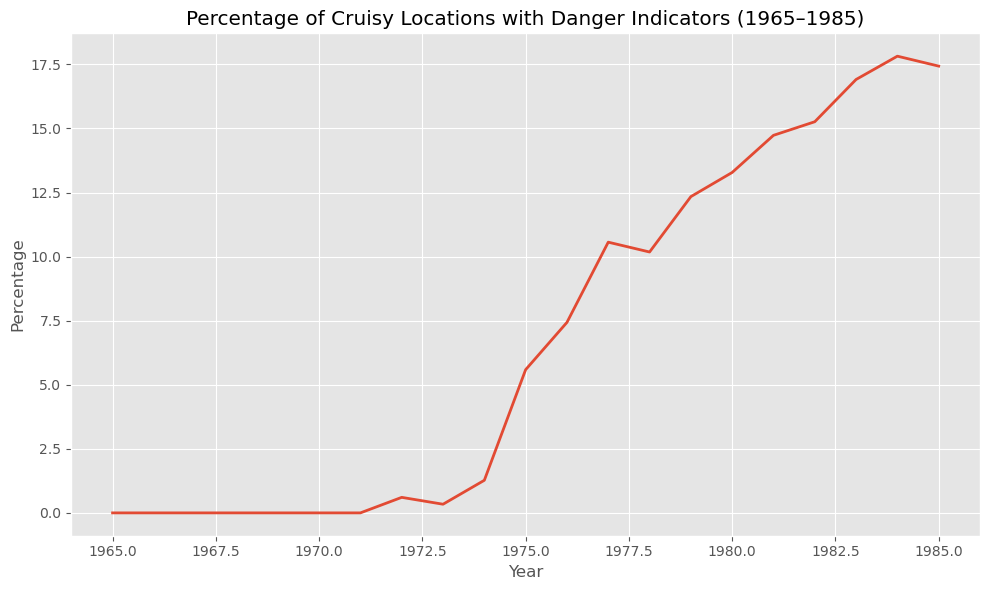

In [10]:
plt.style.use("ggplot")

plt.figure(figsize=(10, 6))
plt.plot(yearly_table.index, yearly_table["Percent_Dangerous"], linewidth=2)

plt.title("Percentage of Cruisy Locations with Danger Indicators (1965–1985)")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.tight_layout()
plt.show()

## Interpreting the Trend

The graph above shows how the proportion of cruising locations marked with danger indicators changes over time. There is a visible upward trend, suggesting that these indicators became more common in later years.

However, a time-series trend alone does not clearly demonstrate historical change. To better evaluate this shift, I compare two distinct time periods.

## Comparing Early and Late Periods

To test whether danger indicators became more prevalent, I divide the data into two periods: 1965–1975 and 1976–1985. I then compute summary statistics for each period to compare their average levels.

In [11]:
def assign_period(year):
    if 1965 <= year <= 1975:
        return "1965-1975"
    elif 1976 <= year <= 1985:
        return "1976-1985"
    return None

period_df = yearly_table.reset_index().rename(columns={"index": "Year"})
period_df["Period"] = period_df["Year"].apply(assign_period)

period_df = period_df.dropna(subset=["Period"])

In [12]:
period_summary = (
    period_df.groupby("Period")["Percent_Dangerous"]
    .agg(["mean", "median", "min", "max", "count"])
    .reset_index()
)

period_summary

,Period,mean,median,min,max,count
0,1965-1975,0.975479,0.168919,0.000000,5.587669,8
1,1976-1985,13.595040,14.006835,7.432432,17.819706,10


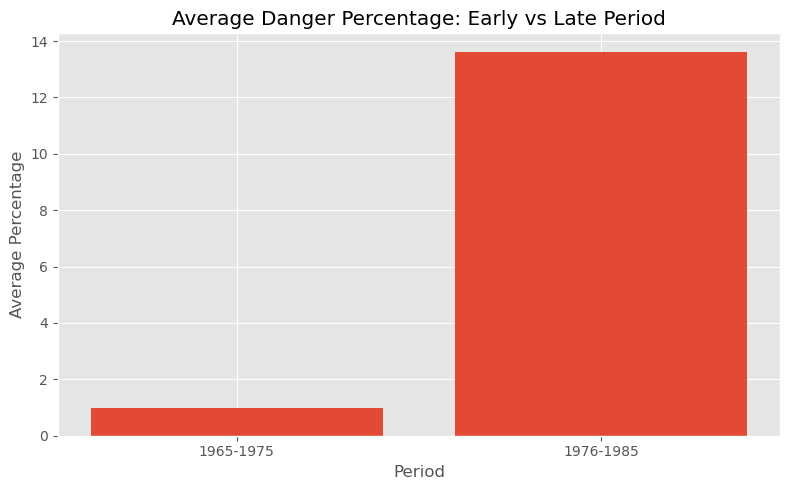

In [13]:
plt.style.use("ggplot")

plt.figure(figsize=(8, 5))
plt.bar(period_summary["Period"], period_summary["mean"])

plt.title("Average Danger Percentage: Early vs Late Period")
plt.xlabel("Period")
plt.ylabel("Average Percentage")
plt.tight_layout()
plt.show()

## Interpreting the Comparison

The bar chart highlights the difference in average danger percentages between the two periods. The later period shows a higher average, supporting the argument that danger indicators became more prominent over time.

In [14]:
early_avg = period_summary.loc[period_summary["Period"] == "1965-1975", "mean"].iloc[0]
late_avg = period_summary.loc[period_summary["Period"] == "1976-1985", "mean"].iloc[0]

print(f"1965-1975 average: {early_avg:.2f}%")
print(f"1976-1985 average: {late_avg:.2f}%")
print(f"Difference: {late_avg - early_avg:.2f} percentage points")

1965-1975 average: 0.98%
1976-1985 average: 13.60%
Difference: 12.62 percentage points


## Robustness Check: Alternative Classification Method

To evaluate how sensitive the results are to methodological choices, I implement a second approach to identifying danger. Instead of relying on predefined labels, this method searches for danger-related keywords in the description field.

This allows me to test whether different data-cleaning strategies produce similar or different historical patterns.

In [15]:
cruisy_alt = df[df["type"] == "Cruising Areas"].copy()

danger_words = ["danger", "police", "arrest", "risk", "avoid", "raid", "watch", "caution"]

def detect_danger(text):
    text = str(text).lower()
    return any(word in text for word in danger_words)

cruisy_alt["danger_flag"] = cruisy_alt["description"].apply(detect_danger)

alt_total_by_year = cruisy_alt.groupby("Year").size()
alt_danger_by_year = cruisy_alt.groupby("Year")["danger_flag"].sum()

alt_table = pd.DataFrame({
    "Total": alt_total_by_year,
    "Danger": alt_danger_by_year
}).fillna(0)

alt_table["Percent"] = (alt_table["Danger"] / alt_table["Total"]) * 100

alt_table.head()

,Total,Danger,Percent
Year,,,
1966,1,0,0.000000
1972,166,0,0.000000
1973,287,0,0.000000
1974,380,2,0.526316
1975,497,3,0.603622


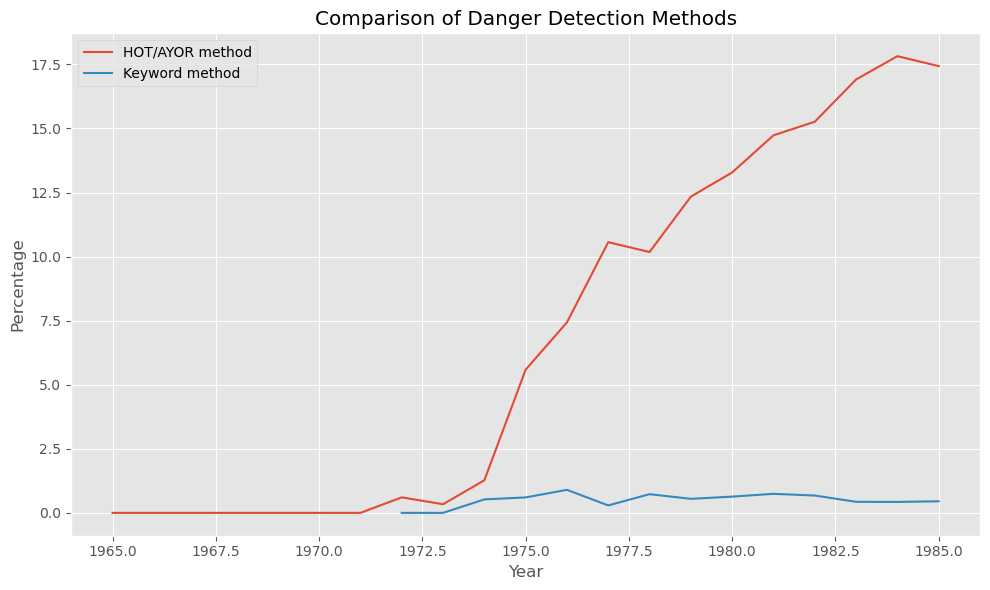

In [16]:
comparison = pd.merge(
    yearly_table.reset_index().rename(columns={"index": "Year"})[["Year", "Percent_Dangerous"]],
    alt_table.reset_index().rename(columns={"index": "Year"})[["Year", "Percent"]],
    on="Year",
    how="outer"
)

plt.figure(figsize=(10, 6))
plt.plot(comparison["Year"], comparison["Percent_Dangerous"], label="HOT/AYOR method")
plt.plot(comparison["Year"], comparison["Percent"], label="Keyword method")

plt.title("Comparison of Danger Detection Methods")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend()
plt.tight_layout()
plt.show()

## Comparing Methods

The comparison above shows that the two methods produce different results in both scale and trend. This demonstrates that the interpretation of historical data can be strongly influenced by how categories are defined and operationalized in the analysis.

## Final Conclusion

This MVP demonstrates a working computational pipeline that moves from raw archival data to a historical argument. The notebook successfully identifies cruising locations, classifies locations marked with danger indicators, and computes yearly and period-based percentages.

The results show that the percentage of cruising locations marked as dangerous increases from the early period (1965–1975) to the later period (1976–1985). This suggests that danger indicators became more prominent over time in the Damron Guides. One possible interpretation is that either conditions became more risky for users of these spaces, or that the guides themselves began to emphasize caution more strongly.

At the same time, the alternative keyword-based method produces a different scale and trend, demonstrating that small changes in data-cleaning and classification can significantly alter the final results. This highlights an important limitation of computational historical analysis: conclusions are shaped not only by the data, but also by the methodological choices used to interpret that data.

Overall, this MVP confirms that the pipeline is technically functional and capable of producing meaningful historical insight. It also suggests that further refinement of classification methods and deeper contextual analysis would be necessary to fully understand the historical significance of these trends.